# 07 — Regression: Tuition Revenue

**Chapter 9 companion.** What predicts how much tuition revenue an institution
collects? The question is useful for enrollment planning, and it exercises the core
regression workflow: an interpretable model with honest standard errors, checks of
its assumptions, cross-validated comparison against flexible learners, and a
principled treatment of a predictor that is missing by policy. Test-optional
admissions mean nearly half of institutions report no SAT scores.

| | |
|---|---|
| Input | `data/analytic/institutions_2023.parquet`: four-year institutions that report admissions data |
| Target | log10 tuition and fee revenue, fiscal 2023 (`TUITION_REVENUE`) |
| Predictors | log10 fall enrollment, admit rate, yield, SAT midpoint, Pell and any-grant shares, log10 in-state tuition and fees 2023-24 (`CHG2AY3`), control |
| Methods | OLS with HC3 standard errors, VIF, residual diagnostics, 5-fold CV of OLS, ridge, lasso, and gradient boosting, missing-data strategies, permutation importance |

Revenue definitions differ between GASB (public) and FASB (private) reporting, so
control enters every model; see notebook 05 for the caveat.

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.1.0 | pandas 3.0.5 | numpy 2.5.3


In [2]:
source = ANALYTIC / "institutions_2023.parquet"
if not source.exists():
    raise FileNotFoundError("Run 01_ingest_clean_deidentify.ipynb first; it builds the analytic table.")

inst = pd.read_parquet(source)
inst = inst[inst["IN_UNIVERSE"]].copy()
print(f"{len(inst):,} institutions in the analysis universe")

5,988 institutions in the analysis universe


## 1. Build the modelling frame

The SAT midpoint averages the 25th and 75th percentiles of the reading and math
sections, giving a composite on the 400-1600 scale. Institutions with an admit rate
of zero or with no positive tuition revenue are excluded, since the log target and
the admissions predictors are undefined for them.

In [3]:
frame = inst[(inst["ICLEVEL"] == 1) & (inst["ADMIT_RATE"] > 0) & (inst["TUITION_REVENUE"] > 0)].copy()
frame["log_tuition"] = np.log10(frame["TUITION_REVENUE"])
frame["log_price"] = np.log10(frame["CHG2AY3"].where(frame["CHG2AY3"] > 0))
frame["SAT_MID"] = frame[["SATVR25", "SATVR75", "SATMT25", "SATMT75"]].sum(axis=1, min_count=4) / 2
frame["SAT_MISSING"] = frame["SAT_MID"].isna().astype(int)
frame["control"] = frame["CONTROL_LABEL"].astype(str)

base_cols = ["LOG_ENROLL", "ADMIT_RATE", "YIELD", "UPGRNTP", "UAGRNTP", "log_price"]
frame = frame.dropna(subset=["log_tuition", *base_cols]).set_index("UNITID")
print(f"{len(frame):,} institutions; {frame['SAT_MISSING'].mean():.0%} report no SAT scores")
frame.groupby("control")["SAT_MISSING"].agg(["size", "mean"]).rename(columns={"size": "institutions", "mean": "share without SAT"})

1,665 institutions; 43% report no SAT scores


,institutions,share without SAT
control,,
Private for-profit,77,0.909
Private not-for-profit,1079,0.452
Public,509,0.305


SAT scores are not missing at random. Whether an institution reports them depends
on its admissions policy, which is related to selectivity and therefore to the
outcome. That rules out simply dropping those institutions without checking what
the drop does to the estimates (section 4).

## 2. An interpretable model: OLS with robust standard errors

Revenue varies by orders of magnitude, and residual spread grows with institutional
size. Heteroskedasticity-consistent (HC3) standard errors remain valid when residual
variance is not constant. On the log scale, the enrollment coefficient is an
elasticity: the percentage change in revenue for a 1% change in enrollment.

In [4]:
import statsmodels.formula.api as smf

formula = "log_tuition ~ LOG_ENROLL + ADMIT_RATE + YIELD + UPGRNTP + UAGRNTP + log_price + C(control)"
ols = smf.ols(formula, data=frame).fit(cov_type="HC3")
print(f"n = {int(ols.nobs):,}; R-squared = {ols.rsquared:.3f}")
ols.summary2().tables[1][["Coef.", "Std.Err.", "P>|z|", "[0.025", "0.975]"]].round(4)

n = 1,665; R-squared = 0.911


,Coef.,Std.Err.,P>|z|,[0.025,0.975]
Intercept,0.903,0.280,0.001,0.353,1.453
C(control)[T.Private not-for-profit],-0.184,0.031,0.000,-0.245,-0.123
C(control)[T.Public],-0.207,0.048,0.000,-0.302,-0.113
LOG_ENROLL,1.044,0.017,0.000,1.010,1.077
ADMIT_RATE,-0.000,0.000,0.963,-0.001,0.001
YIELD,0.002,0.001,0.000,0.001,0.003
UPGRNTP,-0.001,0.001,0.363,-0.002,0.001
UAGRNTP,-0.001,0.001,0.022,-0.002,-0.000
log_price,0.752,0.056,0.000,0.643,0.861


In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

design = ols.model.exog
names = ols.model.exog_names
pd.Series({names[i]: variance_inflation_factor(design, i) for i in range(1, design.shape[1])},
          name="VIF").round(2).to_frame()

,VIF
C(control)[T.Private not-for-profit],6.470
C(control)[T.Public],10.470
LOG_ENROLL,2.170
ADMIT_RATE,1.260
YIELD,2.060
UPGRNTP,1.700
UAGRNTP,1.630
log_price,4.570


A VIF above about 5 means a coefficient's variance is inflated by correlation with
the other predictors. Such a coefficient is imprecise and sensitive to specification,
even though its predictions may be fine. Here the inflated terms are the control
dummies, which overlap heavily with price: public institutions are where low
in-state prices sit.

The R-squared of 0.91 is mostly scale. The enrollment elasticity is close to 1, so
revenue grows in proportion to headcount. The price elasticity of about 0.75 means a
10% higher sticker price goes with about 7.5% more revenue at a given enrollment.
Discounting absorbs part of the list price. Admit rate and Pell share add nothing
once size and price are known.

### Residual diagnostics

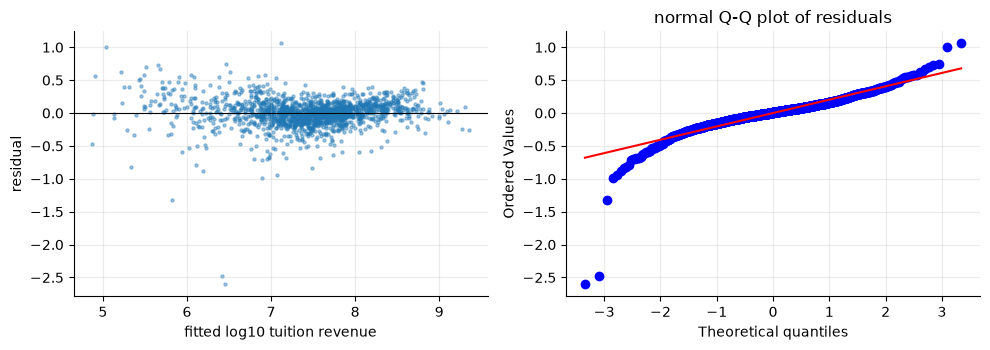

residual skewness -2.19, excess kurtosis 24.13


,INSTNM,control,ENROLL_FALL,TUITION_REVENUE,residual
UNITID,,,,,
262129,New College of Florida,Public,732.000,"7,069.000",-2.606
197221,Webb Institute,Private not-for-profit,105.000,"8,571.000",-2.484
155140,Haskell Indian Nations University,Public,878.000,"31,594.000",-1.328
143978,The Chicago School at Chicago,Private not-for-profit,"1,243.000","150,541,604.000",1.059
486017,Yeshiva Ohr Yisrael,Private not-for-profit,17.000,"1,100,614.000",0.999
199582,Saint Augustine's University,Private not-for-profit,943.000,"791,258.000",-0.994
243115,University of Puerto Rico-Arecibo,Public,"2,831.000","1,336,825.000",-0.941
197993,Bennett College,Private not-for-profit,195.000,"204,281.000",-0.884


In [6]:
from scipy import stats

resid = ols.resid
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].scatter(ols.fittedvalues, resid, s=5, alpha=0.4)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set(xlabel="fitted log10 tuition revenue", ylabel="residual")
stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("normal Q-Q plot of residuals")
save("07_residuals")
print(f"residual skewness {stats.skew(resid):.2f}, excess kurtosis {stats.kurtosis(resid):.2f}")
frame.loc[resid.abs().nlargest(8).index, ["INSTNM", "control", "ENROLL_FALL", "TUITION_REVENUE"]].assign(
    residual=resid.loc[resid.abs().nlargest(8).index])

The residuals are far from normal: long left tail, extreme kurtosis. The largest are
not model failures but institutions whose tuition revenue is near zero by design or
by reporting. Webb Institute is tuition-free, and Haskell Indian Nations University
charges only fees. New College of Florida is the $7,069 anomaly already flagged in
notebook 02. HC3 standard errors protect inference against the unequal spread, but
a handful of such points can still move coefficients. Refitting without them is an
exercise worth doing before any coefficient is reported.

## 3. Cross-validated comparison

In-sample R-squared rewards complexity. Five-fold cross-validation scores every
model on institutions it did not see. RMSE is on the log10 scale, so `10**RMSE` is a
typical multiplicative error: 1.5 means predictions are typically off by a factor of
1.5 in either direction.

Every linear model here handles SAT the same way: median imputation plus a
missingness indicator. Gradient boosting takes the missing values natively.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = [*base_cols, "SAT_MID"]
Xf = frame[num_cols + ["control"]]
y = frame["log_tuition"].to_numpy()
cv = KFold(5, shuffle=True, random_state=SEED)


def linear(model):
    prep = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), num_cols),
        ("cat", OneHotEncoder(drop="first"), ["control"]),
    ])
    return make_pipeline(prep, model)


hgb = make_pipeline(
    ColumnTransformer([("num", "passthrough", num_cols),
                       ("cat", OneHotEncoder(sparse_output=False), ["control"])]),
    HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=SEED))

models = {
    "baseline (mean)": DummyRegressor(),
    "OLS": linear(LinearRegression()),
    "ridge": linear(RidgeCV(alphas=np.logspace(-3, 3, 25))),
    "lasso": linear(LassoCV(cv=5, random_state=SEED)),
    "gradient boosting": hgb,
}
results = {}
for name, model in models.items():
    rmse = -cross_val_score(model, Xf, y, cv=cv, scoring="neg_root_mean_squared_error")
    results[name] = {"RMSE (log10)": rmse.mean(), "fold SD": rmse.std(), "multiplicative error": 10 ** rmse.mean()}
cv_table = pd.DataFrame(results).T
cv_table

,RMSE (log10),fold SD,multiplicative error
baseline (mean),0.733,0.037,5.403
OLS,0.217,0.014,1.650
ridge,0.217,0.014,1.650
lasso,0.217,0.014,1.650
gradient boosting,0.213,0.011,1.634


Regularisation changes nothing, because with nine predictors and 1,665 institutions
OLS is not overfitting. Gradient boosting gains less than 2% in RMSE. The
relationship is close to linear on the log scale, and the interpretable model gives
up almost nothing.

## 4. Handling the test-optional gap

Four strategies, all scored on the same folds with gradient boosting held fixed
where possible, so the only difference is the missing-data choice:

1. Complete cases: keep only institutions that report SAT scores.
2. Drop the variable: use SAT for no one.
3. Median imputation plus an indicator.
4. Native missing handling in gradient boosting.

Complete cases are scored on a different, more selective set of institutions, so
their RMSE is not directly comparable. The fair comparison refits strategies 2-4 on
that subset too.

In [8]:
def cv_rmse(model, data, cols):
    return float(-cross_val_score(model, data[cols], data["log_tuition"], cv=cv,
                                  scoring="neg_root_mean_squared_error").mean())


def ols_on(cols):
    num = [c for c in cols if c != "control"]
    prep = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), num),
        ("cat", OneHotEncoder(drop="first"), ["control"])])
    return make_pipeline(prep, LinearRegression())


with_sat = [*num_cols, "control"]
without_sat = [*base_cols, "control"]
reporters = frame[frame["SAT_MISSING"] == 0]
strategies = pd.DataFrame({
    "all institutions": {
        "drop SAT (OLS)": cv_rmse(ols_on(without_sat), frame, without_sat),
        "impute + indicator (OLS)": cv_rmse(ols_on(with_sat), frame, with_sat),
        "native NaN (boosting)": cv_rmse(hgb, frame, with_sat),
    },
    "SAT reporters only": {
        "complete cases (OLS)": cv_rmse(ols_on(with_sat), reporters, with_sat),
        "drop SAT (OLS)": cv_rmse(ols_on(without_sat), reporters, without_sat),
    },
})
print(f"{len(reporters):,} SAT reporters of {len(frame):,}")
strategies

952 SAT reporters of 1,665


,all institutions,SAT reporters only
drop SAT (OLS),0.219,0.185
impute + indicator (OLS),0.217,NaN
native NaN (boosting),0.213,NaN
complete cases (OLS),NaN,0.184


In [9]:
cc = smf.ols(formula + " + SAT_MID", data=reporters).fit(cov_type="HC3")
full = ols
compare = pd.DataFrame({"all institutions, no SAT": full.params, "SAT reporters, with SAT": cc.params}).loc[
    ["LOG_ENROLL", "ADMIT_RATE", "YIELD", "UPGRNTP", "log_price"]]
compare.round(4)

,"all institutions, no SAT","SAT reporters, with SAT"
LOG_ENROLL,1.044,1.123
ADMIT_RATE,-0.000,0.000
YIELD,0.002,-0.001
UPGRNTP,-0.001,-0.001
log_price,0.752,0.701


For this target the missing-data choice barely matters. Among SAT reporters, adding
SAT improves RMSE by about 0.001; across all institutions the three strategies differ
by less than the fold-to-fold SD. That is a substantive finding, not a null one:
once size and price are known, selectivity carries little information about revenue.
It also shows the complete-case trap. RMSE among reporters (0.18) looks better than
for all institutions (0.22) only because reporters are a more homogeneous group. The
SAT column plays no part in that gap, since dropping it gives the same result on
the same subset.

The coefficients shift between the two samples. The yield coefficient even changes
sign, from 0.002 to -0.001, while the enrollment and price elasticities stay stable.
A coefficient estimated only on SAT reporters describes those institutions, not the
sector.

## 5. Which predictors matter to the flexible model?

Permutation importance measures how much held-out error rises when one predictor is
shuffled. It is computed on a held-out split, not the training data. Correlated
predictors share credit, so a low score can mean "redundant" rather than
"irrelevant".

In [10]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(Xf, y, test_size=0.25, random_state=SEED)
fitted = hgb.fit(X_tr, y_tr)
imp = permutation_importance(fitted, X_te, y_te, n_repeats=20, random_state=SEED,
                             scoring="neg_root_mean_squared_error")
pd.DataFrame({"RMSE increase": imp.importances_mean, "SD": imp.importances_std},
             index=Xf.columns).sort_values("RMSE increase", ascending=False).round(4)

,RMSE increase,SD
LOG_ENROLL,0.880,0.025
log_price,0.197,0.010
UAGRNTP,0.019,0.003
control,0.006,0.001
UPGRNTP,0.006,0.002
YIELD,0.005,0.003
SAT_MID,0.004,0.002
ADMIT_RATE,0.003,0.004


Enrollment dominates and price comes second; everything else is small. Permutation
importance agrees with the OLS table here, which is reassuring but not guaranteed
when predictors are more strongly correlated.

## Exercises

1. Replace the target with log tuition revenue per FTE student. Which predictors
   lose their importance once scale is removed from the outcome?
2. Add an interaction between control and log price. Does the price elasticity
   differ between public and private institutions?
3. Use the ACT composite (`ACTCM25`, `ACTCM75`) where SAT is missing. How many
   institutions does that recover, and does it change the complete-case results?